In [16]:
import random
import torch

n = random.randint(2, 6)
iC = random.randint(2, 6)
oC = random.randint(2, 6)
H = random.randint(10, 20)
W = random.randint(10, 20)
kH = random.randint(2, 6)
kW = random.randint(2, 6)
s = random.randint(2, 6)

input = torch.rand(n, iC, H, W)
kernel = torch.rand(iC, oC, kH, kW)


In [17]:
input.shape

torch.Size([6, 4, 17, 18])

In [18]:
kernel.shape

torch.Size([4, 4, 4, 2])

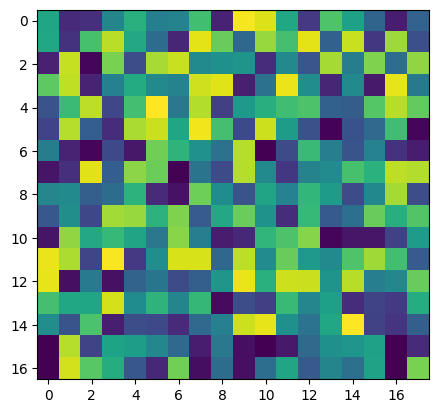

In [19]:
import matplotlib.pyplot as plt

plt.imshow(input[0,0,:,:])

In [20]:
h_out = int((input.shape[2] - kernel.shape[2]) / s + 1)
w_out = int((input.shape[3] - kernel.shape[3]) / s + 1)
output = torch.zeros((input.shape[0], kernel.shape[0], h_out, w_out))
print(f"output.shape = {output.shape}")

output.shape = torch.Size([6, 4, 4, 5])


## Solution 3: `unfold`

In [ ]:
from torch.nn.functional import unfold
# input = ( n, iC, H, W )
# kernel = ( oC, iC, kH, kW )
# output = ( oC, iC, (H - kH)/s + 1, (W - kW)/s + 1 )

input_unfolded = unfold(input, kernel_size=(kernel.shape[2], kernel.shape[3]), stride=s)    # (n, iC * kH * kW, H_out * W_out)
print(f"Input (unfolded): {input_unfolded.shape}")
view_kernel = kernel.view(kernel.shape[0], -1)   # (oC, iC * kH * kW)
print(f"Kernel (unfolded): {view_kernel.shape}")
output_flat = torch.matmul(view_kernel, input_unfolded)     # (n, oC, H_out * W_out)
print(f"Output (unfolded): {output_flat.shape}")
output = output_flat.view(input.shape[0], kernel.shape[0], h_out, w_out)

Input (unfolded): torch.Size([6, 32, 20])
Kernel (unfolded): torch.Size([4, 32])
Output (unfolded): torch.Size([6, 4, 20])


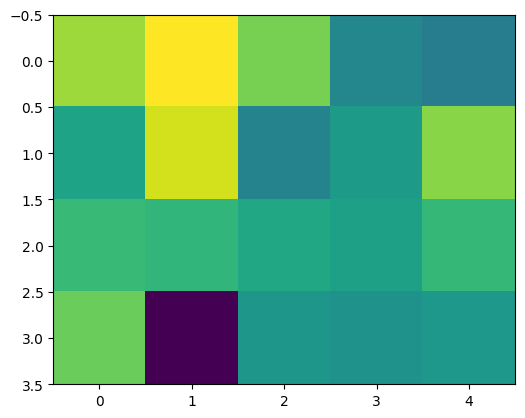

In [22]:
plt.imshow(output[0,0,:,:])